# Checkpoint 3: Outlier Detection & Processing
### Dataset: house_sale.csv

https://www.kaggle.com/datasets/sehriyarmemmedli/binaaz-sale-project

Goal:Detect outliers in the numeric columns of df_clean, justify the choice of method, and process them appropriately.

## 1. df_clean

In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 150)

df = pd.read_csv('house_sale.csv')
df


,id_x,rel_url,estate_rel_url_x,datetime_scrape_x,price,currency_x,location,attributes,city_when,city,day_x,hour_x,repair,vip,featured,products_label,bill_of_sale,mortgage,img_url,id_y,estate_id,estate_rel_url_y,datetime_scrape_y,description,unit_price,total_price,currency_y,owner_name,owner_title,shop_name,shop_title,address,lat,lng,updated,views,day_y,hour_y,estate_details_id_x,Binanın növü,Kateqoriya,Mərtəbə,Otaq sayı,Sahə,Torpaq sahəsi,Təmir,Çıxarış,İpoteka,estate_details_id_y,estate_rel_url,extra_info
0,5df36281-6dc6-4d5d-89a7-5fcfa86f7608,/alqi-satqi?page=174,/items/4521724,2024-10-05 22:07:37.60613+00,499999.0,AZN,Səbail r.,"4 otaqlı, 145 m², 7/9 mərtəbə","Bakı, dünən 23:52",bakı,05.10.2024,23:52,Təmirli,vipped,featured,NaN,Çıxarış var,NaN,https://bina.azstatic.com/uploads/f460x345/202...,92e82ea2-e1f3-4c2d-a284-151efd99281e,5df36281-6dc6-4d5d-89a7-5fcfa86f7608,/items/4521724,2024-10-05 22:14:10.089116+00,"Səbail Rayonu, İzzət Nəbiyev küçəsi, Fəxri Xiy...",3 450 AZN/m²,499999.0,AZN,Kamran,mülkiyyətçi,NaN,NaN,İzzət Nəbiyev küç.,40.358817,49.824092,yeniləndi: dünən 23:52,1155,05.10.2024,23:52,92e82ea2-e1f3-4c2d-a284-151efd99281e,NaN,Köhnə tikili,7 / 9,4.0,145 m²,NaN,var,var,NaN,92e82ea2-e1f3-4c2d-a284-151efd99281e,/items/4521724,Şəhidlər xiyabanı * Dağüstü parkı * Səbail r.
1,883e20f0-8872-49a5-8b4b-63b8301b5f8f,/alqi-satqi?page=250,/items/4669294,2024-10-05 22:07:37.60613+00,77000.0,AZN,Biləcəri q.,"4 otaqlı, 90 m²","Bakı, dünən 23:56",bakı,05.10.2024,23:56,Təmirli,NaN,NaN,NaN,NaN,NaN,https://bina.azstatic.com/uploads/f460x345/202...,505eaf81-6bc8-4094-9b00-aa82066548ee,883e20f0-8872-49a5-8b4b-63b8301b5f8f,/items/4669294,2024-10-05 22:14:10.089116+00,"Biləcəridə Abidəyə yaxin 91,92,202 saylı marşr...",NaN,77000.0,AZN,Dasinmaz Emlak,vasitəçi (agent),NaN,NaN,Biləcəri qəs.,40.420897,49.807035,yeniləndi: 04 oktyabr 2024,218,04.10.2024,NaN,505eaf81-6bc8-4094-9b00-aa82066548ee,NaN,Həyət evi/Bağ evi,NaN,4.0,90 m²,1.3 sot,var,yoxdur,NaN,505eaf81-6bc8-4094-9b00-aa82066548ee,/items/4669294,Binəqədi r.* Biləcəri q.
2,55c36fb1-a3af-476e-ba17-a81f6795be8d,/alqi-satqi?page=250,/items/4669293,2024-10-05 22:07:37.60613+00,92000.0,AZN,İnşaatçılar m.,"3 otaqlı, 60 m²","Bakı, dünən 23:55",bakı,05.10.2024,23:55,Təmirli,NaN,NaN,NaN,Çıxarış var,NaN,https://bina.azstatic.com/uploads/f460x345/202...,fa63b201-999d-43b5-a61a-778d9d79a6c6,55c36fb1-a3af-476e-ba17-a81f6795be8d,/items/4669293,2024-10-05 22:14:10.089116+00,Salam əleykum. \nİnşaatçılar metrosuna yaxın m...,NaN,92000.0,AZN,Məhəmməd,vasitəçi (agent),NaN,NaN,Mirzə Cabbar Məmmədzadə küç.,40.390293,49.802656,yeniləndi: 04 oktyabr 2024,190,04.10.2024,NaN,fa63b201-999d-43b5-a61a-778d9d79a6c6,NaN,Həyət evi/Bağ evi,NaN,3.0,60 m²,0.1 sot,var,var,NaN,fa63b201-999d-43b5-a61a-778d9d79a6c6,/items/4669293,İnşaatçılar m.* Yasamal r.
3,acf1aa8d-a46a-40f5-b6f2-f7a449569337,/alqi-satqi?page=250,/items/4647811,2024-10-05 22:07:37.60613+00,95000.0,AZN,Qaraçuxur q.,130 m²,"Bakı, dünən 23:55",bakı,05.10.2024,23:55,Təmirli,vipped,featured,NaN,Çıxarış var,İpoteka var,https://bina.azstatic.com/uploads/f460x345/202...,5db56980-05cc-4925-b55b-f58fb3f4d2b6,acf1aa8d-a46a-40f5-b6f2-f7a449569337,/items/4647811,2024-10-05 22:14:10.089116+00,Barter maraqlidir üstünlük maşina verilir\nHər...,NaN,95000.0,AZN,Elçin,mülkiyyətçi,NaN,NaN,Qaraçuxur qəs.,40.393614,49.981553,yeniləndi: 04 oktyabr 2024,1314,04.10.2024,NaN,5db56980-05cc-4925-b55b-f58fb3f4d2b6,NaN,Obyekt,NaN,NaN,130 m²,NaN,var,var,var,5db56980-05cc-4925-b55b-f58fb3f4d2b6,/items/4647811,Suraxanı r.* Qaraçuxur q.
4,22d840df-9283-4112-bc71-7432511fc776,/alqi-satqi?page=250,/items/4638863,2024-10-05 22:07:37.60613+00,220000.0,AZN,Əhmədli m.,"3 otaqlı, 100 m², 15/16 mərtəbə","Bakı, dünən 23:52",bakı,05.10.2024,23:52,Təmirli,NaN,NaN,Agentlik,Çıxarış var,NaN,https://bina.azstatic.com/uploads/f460x345/202...,d71cf9a9-86dd-4162-b540-6252a8659a09,22d840df-9283-4112-bc71-7432511fc776,/items/4638863,2024-10-05 22:14:10.089116+00,Əhmədli qəs. Qaçaq Nəbi küçəsi 3 otaga duzelm...

In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100775 entries, 0 to 100774
Data columns (total 51 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   id_x                 100775 non-null  object 
 1   rel_url              100775 non-null  object 
 2   estate_rel_url_x     100775 non-null  object 
 3   datetime_scrape_x    100775 non-null  object 
 4   price                100775 non-null  float64
 5   currency_x           100775 non-null  object 
 6   location             100775 non-null  object 
 7   attributes           100775 non-null  object 
 8   city_when            100775 non-null  object 
 9   city                 100775 non-null  object 
 10  day_x                100775 non-null  object 
 11  hour_x               100775 non-null  object 
 12  repair               81612 non-null   object 
 13  vip                  8596 non-null    object 
 14  featured             3149 non-null    object 
 15  products_label   

In [120]:
df.nunique()

,0
id_x,100775
rel_url,411
estate_rel_url_x,64454
datetime_scrape_x,36
price,2772
currency_x,1
location,142
attributes,21347
city_when,1504
city,8


In [121]:
df_clean = df.copy()
df_clean = df_clean.drop(columns = ["Binanın növü", "hour_y"])

In [122]:
df_clean["featured_flag"] = df_clean["featured"].notnull()
df_clean["vip_flag"] = df_clean["vip"].notnull()
df_clean["mortgage_flag"] = df_clean["mortgage"].notnull()

In [123]:
print("bill_of_sale values:")
print(df_clean["bill_of_sale"].value_counts(dropna = False))

print("\nÇıxarış values:")
print(df_clean["Çıxarış"].value_counts(dropna = False))

df_clean["bill_of_sale_flag"] = (
    df_clean["Çıxarış"]
        .str.strip()
        .str.lower()
        .map({
            "var": 1,
            "yoxdur": 0
        })
)

bill_of_sale values:
bill_of_sale
Çıxarış var    79565
NaN            21210
Name: count, dtype: int64

Çıxarış values:
Çıxarış
var       79565
yoxdur    21210
Name: count, dtype: int64


In [124]:
df_clean = df_clean.drop(columns = [
    "featured",
    "vip",
    "mortgage",
    "İpoteka",
    "bill_of_sale",
    "Çıxarış",
    "repair"
])

In [125]:
df_clean["Təmir"] = df_clean["Təmir"].fillna("Unknown")

In [126]:
df_clean["seller_type"] = "Unknown"
df_clean.loc[df_clean["owner_name"].notna(), "seller_type"] = "Individual"
df_clean.loc[df_clean["shop_name"].notna(), "seller_type"] = "Agency"

In [127]:
for col in ["shop_name", "shop_title", "owner_name", "owner_title"]:
    df_clean[col] = df_clean[col].fillna("N/A")
df_clean["products_label"] = df_clean["products_label"].fillna("Regular listing")
df_clean["description"] = df_clean["description"].fillna("")

In [128]:
def parse_area(val):
    if pd.isnull(val):
        return np.nan
    val = val.strip()
    if "sot" in val:
        return float(val.replace("sot", "").strip().replace(",", ".")) * 100
    return float(val.replace("m²", "").strip().replace(" ", ""))

In [129]:
df_clean["Sahə_numeric"] = df_clean["Sahə"].apply(parse_area)
df_clean["unit_price_calculated"] = (df_clean["price"] / df_clean["Sahə_numeric"]).round(2)
df_clean = df_clean.drop(columns=["unit_price"])

In [130]:
applicable_categories = ["Köhnə tikili", "Yeni tikili", "Ofis", "Həyət evi/Bağ evi"]
mask = df_clean["Kateqoriya"].isin(applicable_categories)
medians = df_clean.loc[mask].groupby("Kateqoriya")["Otaq sayı"].median()
for cat, med in medians.items():
    idx = df_clean[(df_clean["Kateqoriya"] == cat) & (df_clean["Otaq sayı"].isnull())].index
    df_clean.loc[idx, "Otaq sayı"] = med

print("df_clean is ready:", df_clean.shape)

df_clean is ready: (100775, 48)


## 2. Initial look at numeric column distributions

Before choosing an outlier-detection method, I look at the statistical summary and skewness of the key numeric columns.

In [131]:
for col in ["price", "Sahə_numeric", "unit_price_calculated", "views", "Otaq sayı"]:
    print(f"--- {col} ---")
    print(df_clean[col].describe())
    print("skewness:", round(df_clean[col].skew(), 2))
    print()


--- price ---
count    1.007750e+05
mean     3.423557e+05
std      2.042627e+06
min      1.100000e+01
25%      1.450000e+05
50%      2.180000e+05
75%      3.380000e+05
max      6.000000e+08
Name: price, dtype: float64
skewness: 252.31

--- Sahə_numeric ---
count    1.007750e+05
mean     1.128061e+03
std      9.320227e+04
min      1.000000e+00
25%      7.000000e+01
50%      1.050000e+02
75%      1.600000e+02
max      2.000000e+07
Name: Sahə_numeric, dtype: float64
skewness: 152.35

--- unit_price_calculated ---
count    1.007750e+05
mean     2.321759e+03
std      1.042945e+04
min      0.000000e+00
25%      1.675000e+03
50%      2.214290e+03
75%      2.730500e+03
max      3.000000e+06
Name: unit_price_calculated, dtype: float64
skewness: 251.69

--- views ---
count    100775.000000
mean        700.065185
std        1680.672574
min          23.000000
25%          99.000000
50%         254.000000
75%         680.000000
max      113458.000000
Name: views, dtype: float64
skewness: 18.83

---

All variables are heavily right-skewed, indicating that the assumptions of the z-score method are violated. Therefore, IQR is a more appropriate and robust choice.

## 3. A closer look at suspicious extreme values

In [132]:
print("--- Top 5 highest prices ---")
print(df_clean.nlargest(5, "price")[["price", "Kateqoriya", "city", "Sahə"]])
print()
print("--- Top 5 lowest prices ---")
print(df_clean.nsmallest(5, "price")[["price", "Kateqoriya", "city", "Sahə"]])


--- Top 5 highest prices ---
             price   Kateqoriya  city        Sahə
6605   600000000.0  Yeni tikili  bakı      200 m²
6942    60000000.0  Yeni tikili  bakı       50 m²
45825   40000000.0       Torpaq  bakı  200000 sot
72637   39000000.0       Torpaq  bakı     200 sot
8065    36000000.0       Obyekt  bakı     3000 m²

--- Top 5 lowest prices ---
       price         Kateqoriya  city    Sahə
38666   11.0             Obyekt  bakı   89 m²
22304   73.0        Yeni tikili  bakı   90 m²
39775  127.0  Həyət evi/Bağ evi  bakı  150 m²
21745  250.0  Həyət evi/Bağ evi  bakı   30 m²
11322  400.0        Yeni tikili  bakı   86 m²


The highest price (600,000,000 AZN) and the lowest prices (11 AZN, 73 AZN) appear implausible and are likely data-entry errors. However, only clearly impossible low values (below 1,000 AZN) are removed during the sanity check. Extremely high values are retained and handled later using category-specific IQR capping to avoid unnecessarily removing observations before outlier treatment.

In [133]:
print("Rows with price < 1000 AZN:", (df_clean["price"] < 1000).sum())

before = len(df_clean)
df_clean = df_clean[df_clean["price"] >= 1000].copy()
after = len(df_clean)
print(f"Rows removed by the sanity check: {before - after} ({round((before-after)/before*100,3)}% of the dataset)")


Rows with price < 1000 AZN: 10
Rows removed by the sanity check: 10 (0.01% of the dataset)


In [134]:
print(df_clean.nsmallest(10,"price")[["price","Kateqoriya","city"]])

        price Kateqoriya    city
54134  1000.0     Torpaq  xaçmaz
62110  1000.0     Torpaq    bakı
65078  1000.0     Torpaq  xaçmaz
69951  1000.0     Torpaq  xaçmaz
89280  1000.0     Torpaq    bakı
92140  1000.0     Torpaq  xaçmaz
56794  1200.0     Torpaq    bakı
63189  1200.0     Torpaq    bakı
66962  1200.0     Torpaq    bakı
9131   1300.0     Torpaq    bakı


In [135]:
print(df_clean.nlargest(10,"price")[["price","Kateqoriya","city"]])

             price   Kateqoriya  city
6605   600000000.0  Yeni tikili  bakı
6942    60000000.0  Yeni tikili  bakı
45825   40000000.0       Torpaq  bakı
72637   39000000.0       Torpaq  bakı
8065    36000000.0       Obyekt  bakı
31276   36000000.0       Obyekt  bakı
34851   36000000.0       Obyekt  bakı
81161   36000000.0       Obyekt  bakı
69308   26000000.0       Torpaq  bakı
84337   26000000.0       Torpaq  bakı


## 4. IQR-based outlier detection

A plain (global) IQR computes bounds across all rows at once, but in this dataset price scale depends heavily on Kateqoriya. So I compute the IQR bounds separately for each "Kateqoriya", this way a "5-room office selling for 3 million" won't get wrongly excluded, while a "5-room apartment selling for 3 million" will correctly get flagged.


In [136]:
def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

# Global IQR (for comparison)
low_g, high_g = iqr_bounds(df_clean["price"])
global_outliers = ((df_clean["price"] < low_g) | (df_clean["price"] > high_g)).sum()
print(f"Global IQR bounds: [{low_g:,.0f}, {high_g:,.0f}] -> {global_outliers} outliers ({global_outliers/len(df_clean)*100:.2f}%)")


Global IQR bounds: [-144,500, 627,500] -> 7322 outliers (7.27%)


In [137]:
def cap_grouped(df, col, group_col="Kateqoriya", k=1.5):
    """Computes IQR bounds per group, caps outliers at the bounds, and returns a flag column."""
    capped = df[col].copy()
    flag = pd.Series(False, index=df.index)
    bounds_report = {}
    for cat, group in df.groupby(group_col):
        low, high = iqr_bounds(group[col].dropna(), k)
        idx = group.index
        below = df.loc[idx, col] < low
        above = df.loc[idx, col] > high
        flag.loc[idx[below | above]] = True
        capped.loc[idx[below]] = low
        capped.loc[idx[above]] = high
        bounds_report[cat] = (round(low, 1), round(high, 1), int((below | above).sum()))
    return capped, flag, bounds_report


In [138]:
price_capped, price_flag, price_bounds = cap_grouped(df_clean, "price")
print("IQR bounds and outlier count per category (price):")
for cat, (low, high, n) in price_bounds.items():
    print(f"  {cat}: [{low:,.0f}, {high:,.0f}] -> {n} outliers")


IQR bounds and outlier count per category (price):
  Həyət evi/Bağ evi: [-342,500, 877,500] -> 1011 outliers
  Köhnə tikili: [22,500, 282,500] -> 815 outliers
  Obyekt: [-1,400,000, 3,000,000] -> 361 outliers
  Ofis: [-912,500, 2,307,500] -> 11 outliers
  Qaraj: [-17,500, 82,500] -> 3 outliers
  Torpaq: [-465,000, 903,000] -> 688 outliers
  Yeni tikili: [-72,500, 587,500] -> 2958 outliers


In [139]:
print()
print(f"Total grouped outliers: {price_flag.sum()} ({price_flag.mean()*100:.2f}%)")
print(f"(Difference from global method: {global_outliers} -> {price_flag.sum()}, the grouped method is more accurate)")


Total grouped outliers: 5847 (5.80%)
(Difference from global method: 7322 -> 5847, the grouped method is more accurate)


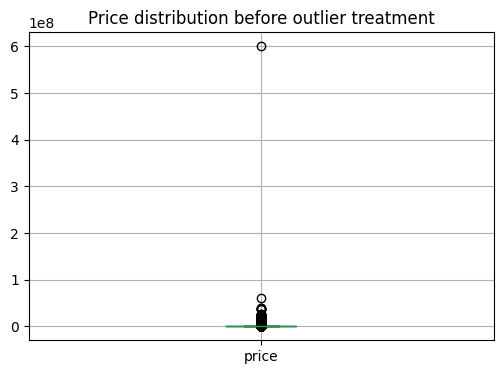

In [140]:
plt.figure(figsize=(6,4))
df_clean.boxplot(column = "price")
plt.title("Price distribution before outlier treatment")
plt.show()

The global IQR flags 7,322 rows (7.3%) as outliers, while the grouped IQR flags 5,847 rows (5.8%), the difference comes from the global method incorrectly treating all "expensive" Obyekt/Torpaq listings as outliers, even though those prices are normal within their own category. For this reason, I'll use category-grouped IQR for all the remaining columns as well.

## 5. Applying to the remaining columns

I apply the same grouped-IQR function to area and the calculated unit price too — since these also have a scale that depends on "Kateqoriya".

In [141]:
area_capped, area_flag, area_bounds = cap_grouped(df_clean, "Sahə_numeric")
print("Sahə_numeric outlier count:", area_flag.sum(), f"({area_flag.mean()*100:.2f}%)")

unit_capped, unit_flag, unit_bounds = cap_grouped(df_clean, "unit_price_calculated")
print("unit_price_calculated outlier count:", unit_flag.sum(), f"({unit_flag.mean()*100:.2f}%)")


Sahə_numeric outlier count: 4077 (4.05%)
unit_price_calculated outlier count: 3352 (3.33%)


## 6. The "views" column

"views" doesn't depend on "Kateqoriya". It's a metadata field reflecting a listing's popularity, driven by factors like how long it's been active rather than the property type. So a global IQR is sufficient here, no grouping needed.

In [142]:
low_v, high_v = iqr_bounds(df_clean["views"])
views_flag = (df_clean["views"] < low_v) | (df_clean["views"] > high_v)
views_capped = df_clean["views"].clip(low_v, high_v)
print(f"views IQR bounds: [{low_v:,.0f}, {high_v:,.0f}] -> {views_flag.sum()} outliers ({views_flag.mean()*100:.2f}%)")


views IQR bounds: [-772, 1,552] -> 10441 outliers (10.36%)


## 7. Capping
I chose capping, not deletion, because:
- Obvious data-entry errors (like the 600M AZN listing) were already removed separately in the sanity.
- Most of the remaining outliers could well be genuine. Deleting them would mean losing the entire "high-end segment" of the dataset, which could matter for future analysis/modeling.
- I also keep an is_outlier_* flag column for each field so it's always visible who was flagged as an outlier (meaning the capped value isn't mandatory to use; it's possible to go back to the original if needed)

In [143]:
df_clean["price_capped"] = price_capped
df_clean["is_outlier_price"] = price_flag

df_clean["Sahə_numeric_capped"] = area_capped
df_clean["is_outlier_area"] = area_flag

df_clean["unit_price_capped"] = unit_capped
df_clean["is_outlier_unit_price"] = unit_flag

df_clean["views_capped"] = views_capped
df_clean["is_outlier_views"] = views_flag

print(df_clean[["price", "price_capped", "is_outlier_price"]].describe())


              price  price_capped
count  1.007650e+05  1.007650e+05
mean   3.423897e+05  2.834652e+05
std    2.042725e+06  2.835427e+05
min    1.000000e+03  1.000000e+03
25%    1.450000e+05  1.450000e+05
50%    2.180000e+05  2.180000e+05
75%    3.380000e+05  3.300000e+05
max    6.000000e+08  3.000000e+06


## 8. Final check : before/after comparison

In [144]:
compare = pd.DataFrame({
    "price (before)": df_clean["price"].describe(),
    "price_capped (after)": df_clean["price_capped"].describe(),
})
compare


,price (before),price_capped (after)
count,1.007650e+05,1.007650e+05
mean,3.423897e+05,2.834652e+05
std,2.042725e+06,2.835427e+05
min,1.000000e+03,1.000000e+03
25%,1.450000e+05,1.450000e+05
50%,2.180000e+05,2.180000e+05
75%,3.380000e+05,3.300000e+05
max,6.000000e+08,3.000000e+06


In [145]:
print(compare.loc[["mean","std","min","max"]])

      price (before)  price_capped (after)
mean    3.423897e+05          2.834652e+05
std     2.042725e+06          2.835427e+05
min     1.000000e+03          1.000000e+03
max     6.000000e+08          3.000000e+06


In [146]:
print("Rows before:", len(df))

print("Rows after:", len(df_clean))

Rows before: 100775
Rows after: 100765


In [147]:
print()

print("Outlier percentage per column:")

for col in [
    "is_outlier_price",
    "is_outlier_area",
    "is_outlier_unit_price",
    "is_outlier_views"
]:
    print(f"{col}: {df_clean[col].mean()*100:.2f}%")


Outlier percentage per column:
is_outlier_price: 5.80%
is_outlier_area: 4.05%
is_outlier_unit_price: 3.33%
is_outlier_views: 10.36%


After reviewing the distribution of the numeric variables, I selected the IQR method because all key variables were heavily right-skewed. Clearly invalid values below 1,000 AZN were removed through a sanity check, while the remaining extreme observations were handled using category-specific IQR capping. This approach preserved potentially valid high-value properties while reducing the influence of extreme observations without removing large portions of the dataset.